In [27]:
import os
import sys
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../BACKEND"))

# Import functions directly from pipeline.py
from pipeline import load_api_key, pipeline

In [28]:
api_key = load_api_key()
# el = pipeline(api_key=api_key, platform='EUW1', player_name='401dmg', player_tag='6969', count=1, save=1) #H2P_Gucio

from pathlib import Path

base_dir = Path.cwd()
data = {}

for file_path in sorted(base_dir.glob('data_full_[1-6].json')):
    with open(file_path, encoding='utf-8') as f:
        data.update(json.load(f))

print(f'Loaded {len(data)} matches from {len(list(base_dir.glob("data_full_[1-4].json")))} files.')

Loaded 252 matches from 4 files.


Dropping unnecesarry columns with irrelevant data

In [29]:
players = []
for match in data.values():
    for player in match['players']:
        players.append(player)
        
    df = pd.DataFrame(players)    
    df = df.drop(columns=['username', 'championImageLink', 'summonerLevel', 'teamId', 'goldEarned', 'needVisionPings', 'enemyVisionPings', 'allInPings', 'pushPings',
        'assistMePings', 'commandPings', 'dangerPings', 'enemyMissingPings', 'gameEndedInSurrender',
        'onMyWayPings', 'retreatPings', 'icon', 'caller', 'masteries'])
        
    df = df.set_index('puuid')

Handling nested json object

In [30]:
df["summoner_1"] = df["summoners"].str[0].str["name"]
df["summoner_2"] = df["summoners"].str[1].str["name"]
df = df.drop(columns=['summoners', 'runes', 'items', 'metadata'])

Splitting summoner spells 

In [31]:
summs_ohe = pd.get_dummies(df[["summoner_1", "summoner_2"]], dtype=int)

spell_to_columns = {}
for col in summs_ohe.columns:
    spell_name = col.replace("summoner_1_", "").replace("summoner_2_", "")
    spell_to_columns.setdefault(spell_name, []).append(col)

summoners_encoded = pd.DataFrame(
    {f"summoner_{spell}": summs_ohe[cols].max(axis=1) for spell, cols in spell_to_columns.items()},
    index=df.index,
    )

final_df = pd.concat([df, summoners_encoded], axis=1)

In [32]:
final_df = final_df.drop(columns=['summoner_1', 'summoner_2'])

In [33]:
final_df.head()

,teamPosition,championName,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,...,totalTimeSpentDead,summoner_Barrier,summoner_Cleanse,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
u4VV2W_XrZvi0dBpxx8YHCc_w8Zh3vv7fAalveS_ZVRJ1qCAAfc7sN-v6hRviAQKSnBN8xVvG5FzdA,TOP,Aurora,2,7,13,18,2.14,31.25,181,19,...,236,0,0,1,1,0,0,0,0,0
n4roh57gtRaoM56CllkyVY88VD3E0wpS_PIqDftlK4tQ_F-fQ_ihrVTuQ7RQFnZRDzSAWoTiaK15vw,JUNGLE,Kindred,10,12,9,18,1.58,39.58,39,37,...,452,0,0,0,1,0,0,0,1,0
t82fTNAvlp3bpyNouXA4UFAchaxt_6QYgHwi9T8pUmSIi7BhaKfhWdn-LL26xOUcLqSfoC5qeJAGdQ,MIDDLE,Sylas,10,6,17,18,4.50,56.25,129,27,...,187,0,0,1,1,0,0,0,0,0
r6X3JJwPf3QvD2UL0_4E-vJN_n0C-ZTUIRc4VUfyzEEqMLxmovdgRHZvBCG6gxEhsUtP_bBcufsvdA,BOTTOM,Jhin,25,6,8,18,5.50,68.75,43,20,...,158,1,0,0,1,0,0,0,0,0
_gbn85lupm3ObLIagw7dPTU3lA5a8C6JZmpHJPcCt2ZpvR6CVpOog6W6NaYVNbOInYQvoMsyM0pe6A,UTILITY,Rell,1,11,33,16,3.09,70.83,114,0,...,343,0,0,0,1,0,0,1,0,0


Spliting data into index table and statistics values table

In [34]:
index_table_df = final_df[["teamPosition", "championName"]].copy()
index_table_df.insert(0, "puuid", final_df.index)

numerical_stats_df = final_df.drop(columns=["teamPosition", "championName"])
numerical_stats_df['win'] = numerical_stats_df['win'].astype(int)
numerical_stats_df = numerical_stats_df.select_dtypes(include=["number"]).copy()

Normalization of values inside stats table. Min-max normalization to values $x \in [0, 1]$

In [35]:
# Min-max normalization to [0, 1]
normalized_stats_df = numerical_stats_df.copy()

for col in normalized_stats_df.columns:
    min_col_value = normalized_stats_df[col].min()
    max_col_value = normalized_stats_df[col].max()

    if max_col_value == min_col_value:
        normalized_stats_df[col] = 0.0
    else:
        normalized_stats_df[col] = (
            (normalized_stats_df[col] - min_col_value)
            / (max_col_value - min_col_value)
        )

Coefficent matrix is plotted to verify data connections.

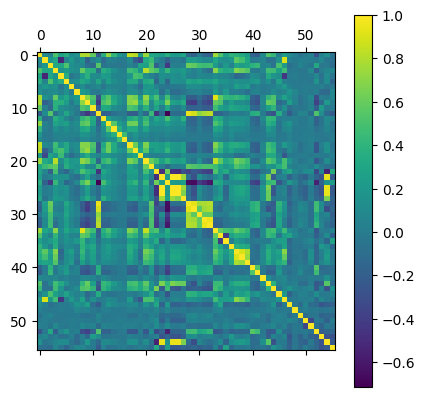

In [36]:
plt.matshow(normalized_stats_df.corr())
plt.colorbar()

In [37]:
normalized_stats_df.head()

,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,damagePerMinute,goldPerMinute,...,totalTimeSpentDead,summoner_Barrier,summoner_Cleanse,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
u4VV2W_XrZvi0dBpxx8YHCc_w8Zh3vv7fAalveS_ZVRJ1qCAAfc7sN-v6hRviAQKSnBN8xVvG5FzdA,0.066667,0.368421,0.282609,0.894737,0.056316,0.3125,0.507003,0.026099,0.311117,0.270151,...,0.347059,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
n4roh57gtRaoM56CllkyVY88VD3E0wpS_PIqDftlK4tQ_F-fQ_ihrVTuQ7RQFnZRDzSAWoTiaK15vw,0.333333,0.631579,0.195652,0.894737,0.041579,0.3958,0.109244,0.050824,0.342728,0.426437,...,0.664706,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
t82fTNAvlp3bpyNouXA4UFAchaxt_6QYgHwi9T8pUmSIi7BhaKfhWdn-LL26xOUcLqSfoC5qeJAGdQ,0.333333,0.315789,0.369565,0.894737,0.118421,0.5625,0.361345,0.037088,0.531107,0.448964,...,0.275000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
r6X3JJwPf3QvD2UL0_4E-vJN_n0C-ZTUIRc4VUfyzEEqMLxmovdgRHZvBCG6gxEhsUtP_bBcufsvdA,0.833333,0.315789,0.173913,0.894737,0.144737,0.6875,0.120448,0.027473,0.616273,0.764578,...,0.232353,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
_gbn85lupm3ObLIagw7dPTU3lA5a8C6JZmpHJPcCt2ZpvR6CVpOog6W6NaYVNbOInYQvoMsyM0pe6A,0.033333,0.578947,0.717391,0.789474,0.081316,0.7083,0.319328,0.000000,0.161793,0.221912,...,0.504412,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Association rules for the win attribute use a binary view of the normalized stats. In this notebook, trust is treated as confidence.

In [40]:
from mlxtend.frequent_patterns import apriori, association_rules

# Convert normalized values into presence/absence items for rule mining
# 'high_' means the normalized value is at least 0.5.
binary_stats_df = normalized_stats_df.drop(columns=['win']).ge(0.5)
binary_stats_df = binary_stats_df.rename(columns=lambda col: f'high_{col}')
binary_stats_df['win'] = normalized_stats_df['win'].ge(0.5)

frequent_itemsets = apriori(binary_stats_df, min_support=0.1, use_colnames=True)

if frequent_itemsets.shape[0] < 1:
    win_rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'trust', 'lift'])
else:
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
    win_rules = rules[rules['consequents'] == frozenset({'win'})].copy()
    win_rules['trust'] = win_rules['confidence']
    win_rules = win_rules.sort_values(['trust', 'support', 'lift'], ascending=False)

def itemset_to_text(itemset):
    readable_items = []
    for item in sorted(itemset):
        if item == 'win':
            readable_items.append('win')
        elif item.startswith('high_'):
            readable_items.append(f'high {item[5:]}')
        else:
            readable_items.append(item)
    return ' and '.join(readable_items)

win_rules_display = win_rules.assign(
    antecedents=win_rules['antecedents'].map(itemset_to_text),
    consequents=win_rules['consequents'].map(itemset_to_text),
    support=win_rules['support'].round(3),
    trust=win_rules['trust'].round(3),
    lift=win_rules['lift'].round(3),
)

win_rules_display[['antecedents', 'consequents', 'support', 'trust', 'lift']]

,antecedents,consequents,support,trust,lift
134,high cs_min and high goldPerMinute,win,0.206,0.739,1.479
287,high cs_min and high goldPerMinute and high su...,win,0.198,0.739,1.477
203,high champLevel and high cs_min and high goldP...,win,0.202,0.737,1.474
346,high champLevel and high cs_min and high goldP...,win,0.195,0.736,1.472
22,high goldPerMinute,win,0.215,0.734,1.469
138,high goldPerMinute and high summoner_Flash,win,0.207,0.734,1.468
61,high champLevel and high goldPerMinute,win,0.211,0.732,1.464
211,high champLevel and high goldPerMinute and hig...,win,0.203,0.731,1.463
308,high champLevel and high cs_min and high goldP...,win,0.113,0.688,1.375
270,high cs_min and high goldPerMinute and high ki...,win,0.114,0.687,1.375
